<a href="https://colab.research.google.com/github/timjin06/Cinema-Guide-Project/blob/main/NLP_asgmt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gdown
import pandas as pd

# 명진님의 파일 ID로 설정됨
file_id = '1vFZmn-8XZzZl9b2Y9z5UbdjAXZHMO7aE'

# 코랩 환경에 저장될 파일 이름
output_filename = 'filtered_reddit_data.xlsx'

# 구글 드라이브에서 다운로드 (직접 다운로드 링크 생성)
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, output_filename, quiet=False)

print(f"File '{output_filename}' downloaded successfully!")

# 엑셀 파일이므로 read_excel 사용
df_raw = pd.read_excel(output_filename)

# 데이터 상위 5개 행 확인
display(df_raw.head())

Downloading...
From: https://drive.google.com/uc?id=1vFZmn-8XZzZl9b2Y9z5UbdjAXZHMO7aE
To: /content/filtered_reddit_data.xlsx
100%|██████████| 10.4M/10.4M [00:00<00:00, 13.7MB/s]


File 'filtered_reddit_data.xlsx' downloaded successfully!


,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
0,k857c4c,3,Would you be able to post links to the indepen...,IsraelPalestine,2023-11-06 23:59:00,17p73rm,Alive_Collection_454,0,3,0,...,20,924,944,62,My buddy and I were discussing over the situat...,Is Hamas lying when releasing numbers of fatal...,0.74,62,0,2023-11-06 16:50:00
1,k857b4l,13,Of course it's important. Until the 20th centu...,IsraelPalestine,2023-11-06 23:59:00,17pdtfd,kawaii_war_dandy,0,13,0,...,685,8579,9264,57,I just read in the [New York Times](https://ww...,How does the Al Shifa hospital house 60 000 pe...,0.85,57,0,2023-11-06 21:36:00
2,k857amm,1,"ISW, the conservative think tank representing ...",IsraelPalestine,2023-11-06 23:59:00,17p76sb,Having_A_Day,0,1,0,...,3,3052,3055,31,Now that the IDF has boots on the ground in Ga...,Public Reaction to Ground Footage,0.82,31,0,2023-11-06 16:54:00
3,k8579mi,1,###[View link](https://rapidsave.com/info?url=...,NonCredibleDefense,2023-11-06 23:59:00,17obtsm,SaveVideo,0,1,0,...,15073,641575,656648,1433,NaN,Hamas Air Support in a nutshell,0.96,1433,0,2023-11-05 13:21:00
4,k8578wh,14,I find it extremely unlikely that these specia...,CombatFootage,2023-11-06 23:59:00,17p7mfx,what-the-puck,0,14,0,...,1095,166322,169946,11536,NaN,Better footage of the israeli special forces a...,0.94,11536,0,2023-11-06 17:12:00


In [3]:
# 1.1 변수 목록 및 데이터 타입 확인
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46290 entries, 0 to 46289
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   comment_id                  46290 non-null  object        
 1   score                       46290 non-null  int64         
 2   self_text                   46287 non-null  object        
 3   subreddit                   46290 non-null  object        
 4   created_time                46290 non-null  datetime64[ns]
 5   post_id                     46290 non-null  object        
 6   author_name                 46268 non-null  object        
 7   controversiality            46290 non-null  int64         
 8   ups                         46290 non-null  int64         
 9   downs                       46290 non-null  int64         
 10  user_is_verified            46290 non-null  bool          
 11  user_account_created_time   44072 non-null  datetime64

In [8]:
# 1.2 카테고리형/텍스트 변수의 고유값 수 세기

# object 타입(문자열)인 컬럼만 골라서 cat_cols에 저장
cat_cols = df_raw.select_dtypes(include='object').columns

# 각 카테고리 컬럼별로 고유값이 몇 개인지 카운트
# nunique() = number of unique values (중복 제거한 고유값 수)
df_raw[cat_cols].nunique()

,0
comment_id,46290
self_text,45729
subreddit,12
post_id,942
author_name,22825
post_self_text,257
post_title,936


In [9]:
# 1.3 수치형 데이터 기술 통계
df_raw.describe()

,score,created_time,controversiality,ups,downs,user_account_created_time,user_awardee_karma,user_awarder_karma,user_link_karma,user_comment_karma,user_total_karma,post_score,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
count,46290.000000,46290,46290.000000,46290.000000,46290.0,44072,46290.000000,46290.000000,4.629000e+04,4.629000e+04,4.629000e+04,46290.000000,46290.000000,46290.000000,46290.0,46290
mean,40.733204,2023-10-28 09:38:07.564484864,0.071722,40.733204,0.0,2019-01-04 15:07:40.225539840,319.778959,173.299762,1.606060e+04,5.918396e+04,7.573764e+04,2606.947742,0.864331,2606.947742,0.0,2023-10-27 21:44:35.320803840
min,-980.000000,2023-09-23 01:31:00,0.000000,-980.000000,0.0,2006-01-21 21:37:00,0.000000,0.000000,0.000000e+00,-1.000000e+02,-9.900000e+01,0.000000,0.050000,0.000000,0.0,2023-09-07 13:08:00
25%,1.000000,2023-10-24 00:56:15,0.000000,1.000000,0.0,2016-08-21 14:00:00,0.000000,0.000000,3.800000e+01,2.710000e+03,3.662250e+03,562.000000,0.850000,562.000000,0.0,2023-10-23 14:05:00
50%,5.000000,2023-10-31 08:06:30,0.000000,5.000000,0.0,2020-01-04 17:52:00,0.000000,0.000000,7.120000e+02,1.577850e+04,1.967400e+04,1855.000000,0.920000,1855.000000,0.0,2023-10-30 17:46:00
75%,19.000000,2023-11-03 14:55:00,0.000000,19.000000,0.0,2021-11-03 09:32:45,146.000000,15.000000,4.990000e+03,5.787825e+04,6.755100e+04,3820.000000,0.950000,3820.000000,0.0,2023-11-03 05:31:00
max,9688.000000,2023-11-06 23:59:00,1.000000,9688.000000,0.0,2023-11-04 16:45:00,102296.000000,89697.000000,9.051118e+06,4.428997e+06,9.874145e+06,19806.000000,1.000000,19806.000000,0.0,2023-11-06 23:49:00
std,206.315928,NaN,0.258029,206.315928,0.0,NaN,1823.401939,1368.627366,2.042978e+05,1.337950e+05,2.697445e+05,2840.907530,0.150058,2840.907530,0.0,NaN


In [7]:
df_raw.isnull().sum().sort_values(ascending=False)
# 1.4 결측치(데이터 빈칸) 확인

,0
post_self_text,37678
user_account_created_time,2218
author_name,22
self_text,3
subreddit,0
created_time,0
score,0
comment_id,0
controversiality,0
post_id,0


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2.1 score 변수의 기본 통계
# .mean() = 평균값 계산
# .min()  = 최솟값 계산
# .max()  = 최댓값 계산
# :.2f    = 소수점 둘째 자리까지 표시
print(f"Mean: {df_raw['score'].mean():.2f}")
print(f"Min:  {df_raw['score'].min():.2f}")
print(f"Max:  {df_raw['score'].max():.2f}")

Mean: 40.73
Min:  -980.00
Max:  9688.00


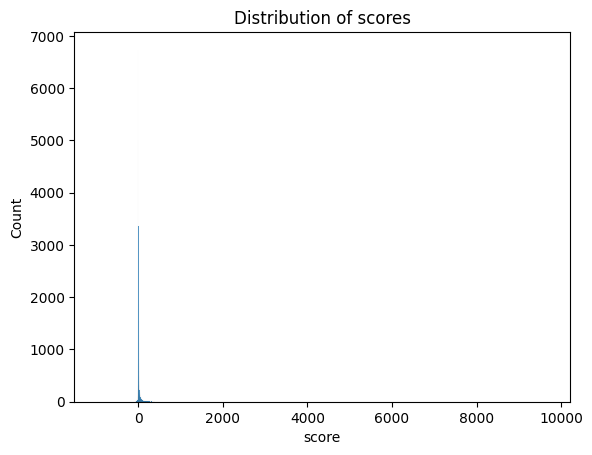

In [19]:
# 2.2 score 변수의 원본 분포 히스토그램 시각화

# sns.histplot() = 히스토그램 그리는 함수
# kde=False = 부드러운 곡선(커널밀도) 없이 막대만 표시
sns.histplot(df_raw['score'], kde=False)

# 그래프 제목 설정
plt.title('Distribution of scores')

# 그래프 화면에 출력
plt.show()

In [12]:
# 2.3 Z-score 변환
# z-score = 각 값이 평균에서 얼마나 떨어져 있는지 표준편차 단위로 표현
# 공식: (x - 평균) / 표준편차
df_raw['zscore'] = df_raw['score'].apply(
    lambda x: (x - df_raw['score'].mean()) / df_raw['score'].std()
)

# score와 zscore 컬럼만 골라서 상위 5개 행 확인
# .head() = 상위 5개 행 출력 (결과 확인용)
df_raw[['score', 'zscore']].head()

,score,zscore
0,3,-0.182890
1,13,-0.134421
2,1,-0.192584
3,1,-0.192584
4,14,-0.129574


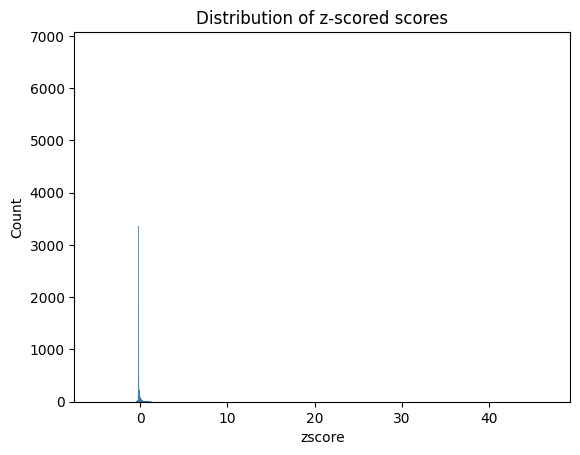

In [13]:
# 2.4 z-score 분포 히스토그램 시각화

# 2.3에서 만든 zscore 컬럼으로 히스토그램 그리기
# kde=False = 부드러운 곡선 없이 막대만 표시
sns.histplot(df_raw['zscore'], kde=False)

# 그래프 제목 설정
plt.title('Distribution of z-scored scores')

# 그래프 출력
plt.show()

### **2.5 Interpretation**
The distribution of the score variable is strongly right-skewed,
with most comments clustered near 0-10 but a long tail extending to 9688,
pulling the mean (40.7) far above the median (5.0).

After applying the z-score transformation, the data is recentered at 0
with standard deviation 1, making outliers easier to identify.

483 comments have z > 3, representing exceptionally upvoted viral comments,
while only 2 comments have z < -3, indicating heavily downvoted cases.

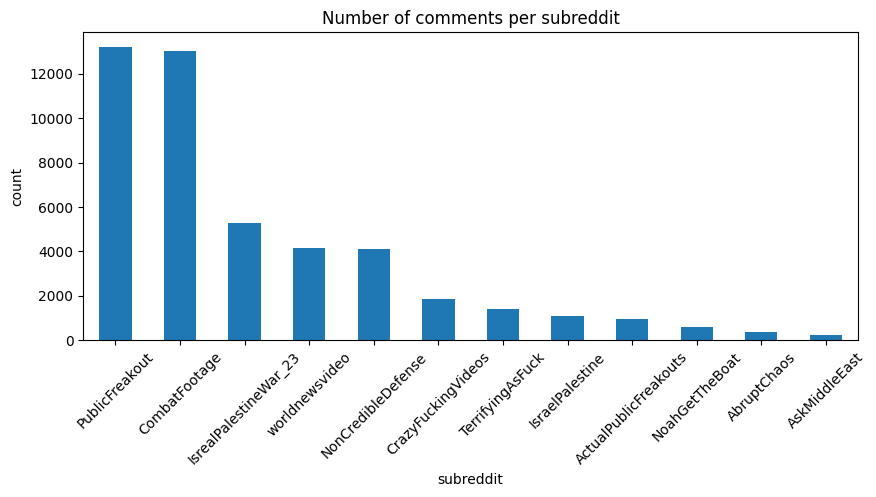

Most frequent:  PublicFreakout (13206)
Least frequent: AskMiddleEast (231)


In [20]:
# 3.1 subreddit 카테고리 빈도 세기

# value_counts() = 각 카테고리가 몇 번 등장하는지 세는 함수
subreddit_counts = df_raw['subreddit'].value_counts()

# 막대그래프로 시각화
# kind='bar' = 막대그래프
# figsize=(10, 4) = 그래프 가로10, 세로4 크기
# title = 그래프 제목
subreddit_counts.plot(kind='bar', figsize=(10, 4), title='Number of comments per subreddit')

# y축 라벨 설정
plt.ylabel('count')

# x축 라벨이 겹치지 않게 45도 회전
plt.xticks(rotation=45)

plt.show()

# 가장 많은/적은 subreddit 출력
# idxmax() = 가장 큰 값의 인덱스(카테고리 이름) 반환
# idxmin() = 가장 작은 값의 인덱스(카테고리 이름) 반환
print(f"Most frequent:  {subreddit_counts.idxmax()} ({subreddit_counts.max()})")
print(f"Least frequent: {subreddit_counts.idxmin()} ({subreddit_counts.min()})")

In [21]:
# 3.2 subreddit별 평균 score 계산

# groupby('subreddit') = subreddit 기준으로 그룹 묶기
# ['score'] = score 컬럼 선택
# .mean() = 각 그룹의 평균 계산
# .sort_values(ascending=False) = 높은 순서대로 정렬
subreddit_means = df_raw.groupby('subreddit')['score'].mean().sort_values(ascending=False)

# 결과 출력
subreddit_means

,score
subreddit,
PublicFreakout,66.480312
NonCredibleDefense,46.025889
CrazyFuckingVideos,45.239260
ActualPublicFreakouts,42.937178
CombatFootage,41.298401
NoahGetTheBoat,40.942434
TerrifyingAsFuck,37.832153
AbruptChaos,26.435443
AskMiddleEast,14.090909


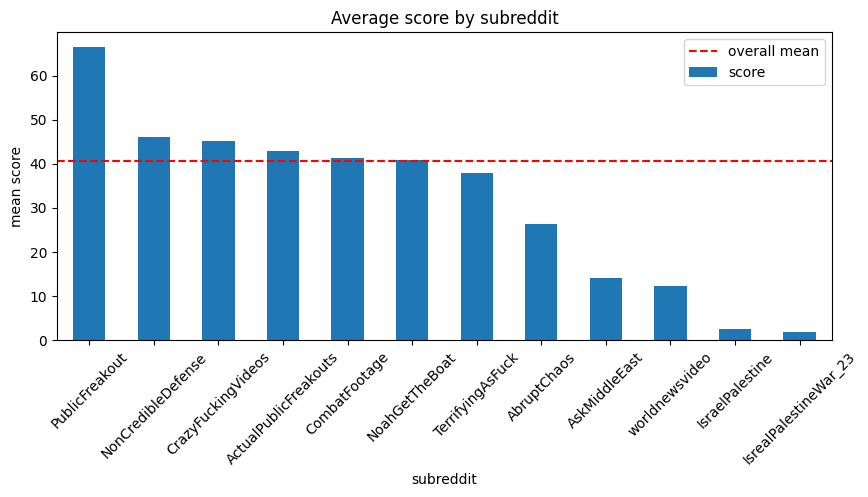

In [22]:
# 3.3 subreddit별 평균 score 막대그래프 시각화

# kind='bar' = 막대그래프
# figsize=(10, 4) = 그래프 크기
# title = 그래프 제목
subreddit_means.plot(kind='bar', figsize=(10, 4), title='Average score by subreddit')

# y축 라벨 설정
plt.ylabel('mean score')

# 전체 평균선 추가
# axhline() = 수평선 그리기
# color='red' = 빨간색
# linestyle='--' = 점선
# label = 범례에 표시될 이름
plt.axhline(df_raw['score'].mean(), color='red', linestyle='--', label='overall mean')

# 범례 표시 (overall mean 선 설명)
plt.legend()

# x축 라벨 45도 회전 (겹치지 않게)
plt.xticks(rotation=45)

plt.show()

### **3.4 Short Interpretation:**

PublicFreakout has the highest average score (66.5), followed by NonCredibleDefense (46.0)
and CrazyFuckingVideos (45.2), while IsraelPalestine (2.5) and IsrealPalestineWar_23 (1.9)
sit at the bottom.

The spread across subreddits (~65 points) is relatively small compared to the overall
std (~206) observed in section 2, suggesting that subreddit membership alone does not
strongly determine comment score.

AskMiddleEast and AbruptChaos have very few comments (231 and 395 respectively),
so their group means should be interpreted with caution.

In [23]:
# 4.1 score 컬럼의 결측값 확인

# isnull() = 각 값이 결측값(NaN)인지 True/False로 반환
# .sum() = True(결측값)의 개수를 합산
print(f"Missing score: {df_raw['score'].isnull().sum()}")

# 결측값이 있는 행 제거
# dropna(subset=['score']) = score 컬럼이 결측값인 행만 제거
# 다른 컬럼의 결측값은 무시
df_clean = df_raw.dropna(subset=['score'])

# 제거 전후 행 수 비교
print(f"Rows before: {len(df_raw)}, after dropna: {len(df_clean)}")

Missing score: 0
Rows before: 46290, after dropna: 46290


In [32]:
# 4.2 필터링: score가 높은 댓글 선택

# 단일 조건: score가 10 초과인 댓글
# > 10 = 10점 초과인 행만 선택
high_score = df_clean[df_clean['score'] > 10]

# 복합 조건: score가 10 초과 AND 논란 없는 댓글
# controversiality == 0 = 논란도가 0인 댓글 (논란 없음)
# & = 두 조건 모두 만족하는 행만 선택
high_and_clean = df_clean[(df_clean['score'] > 10) & (df_clean['controversiality'] == 0)]


In [33]:
# 4.3 필터링 결과 보고
print("Step 4.3: Reporting results...")

print(f"Comments with score > 10: {len(high_score)}")
print(f"High score & non-controversial: {len(high_and_clean)}")

high_and_clean[['subreddit', 'score', 'ups', 'author_name']].head(10)

Step 4.3: Reporting results...
Comments with score > 10: 15943
High score & non-controversial: 15595


,subreddit,score,ups,author_name
1,IsraelPalestine,13,13,kawaii_war_dandy
4,CombatFootage,14,14,what-the-puck
7,NonCredibleDefense,113,113,eigenman
10,CombatFootage,170,170,TheMasterXXXXX
14,NonCredibleDefense,191,191,Daveallen10
16,NoahGetTheBoat,27,27,Amoki602
27,AskMiddleEast,13,13,ramz66
38,CombatFootage,69,69,DrCrankSumMoore
40,AskMiddleEast,12,12,JourneyThiefer
42,NonCredibleDefense,26,26,BrendBurgun


### **4.4 Short Interpretation**

This filtering was not intended to remove low-quality data,
but to examine a specific subset of comments with higher engagement.

Low-score comments are equally valid data points and remain
in the full dataset for overall analysis — score alone does not
determine the importance or quality of a comment.

This subset may reflect more visible or widely supported opinions,
but should not be treated as more representative than the full dataset.

교수님께서 말씀해주신 피드백중에 스코어 갯수를 바탕으로 마음대로 가중치를 조절해서는 안된다고 한 것을 최대한 반영하여서 설명하려고 노력했습니다.

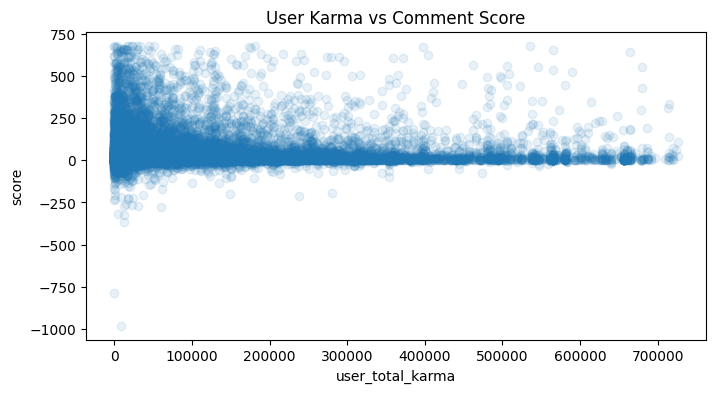

카르마 - score 상관계수: 0.026


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# 카르마는 사용자가 올린 게시물(Post)이나 댓글이 다른 사용자들로부터 받은 '추천'평판 포인트이다. 네이버 지식인에 '영웅','수호신'같은 개념이다. 결국 이 카르마가 높은 유저일 수록 score가 높은지 궁금해서 추가로 진행해봤다.
####### 분석 1번 카르마가 높은 유저일수록 score도 높은가? #####

# 카르마와 score 둘 다 이상치 제거 (z-score 기준 -3 ~ 3)
df_filtered = df_raw[
    (df_raw['user_total_karma'] < df_raw['user_total_karma'].quantile(0.99)) &
    (df_raw['score'] < df_raw['score'].quantile(0.99))
]

# 산점도 그리기
# scatter plot = 두 변수의 관계를 점으로 표현, 이번엔 히트맵과 비슷하게 산점도로 표현해보았습니다!!!!
plt.figure(figsize=(8, 4))
plt.scatter(df_filtered['user_total_karma'], df_filtered['score'], alpha=0.1)
plt.title('User Karma vs Comment Score')
plt.xlabel('user_total_karma')
plt.ylabel('score')
plt.show()

# 상관계수 계산
# corr() = -1 ~ 1 사이 값, 1에 가까울수록 양의 상관관계
corr1 = df_raw['user_total_karma'].corr(df_raw['score'])
print(f"카르마 - score 상관계수: {corr1:.3f}")

# **Analysis 1: User Karma vs Comment Score**

결론적으로 상관계수가 0.026 이므로 1에 한참 못 미쳐 상관관계가 거의 없음으로 들어났습니다. 즉 카르마가 높은 유저이든 카르마가 거의 없는 유저이든 스코어는 0에 몰려있었으며, 오히려 카르마가 높은 유저들이 0에 많이 몰려있는 모습을 볼수있었습니다. 즉 카르마가 올라가도 딱히 score가 높아지는 것은 아니라는 결론입니다.

The correlation coefficient of 0.026 is far below 1,
indicating almost no relationship between user karma and comment score.

Regardless of whether a user has high or low karma,
comment scores tend to cluster around 0.
Interestingly, users with higher karma showed an even stronger
concentration near 0.

In conclusion, higher karma does not lead to higher comment scores,
suggesting that comment score is driven more by content and timing
than by the user's overall Reddit activity.

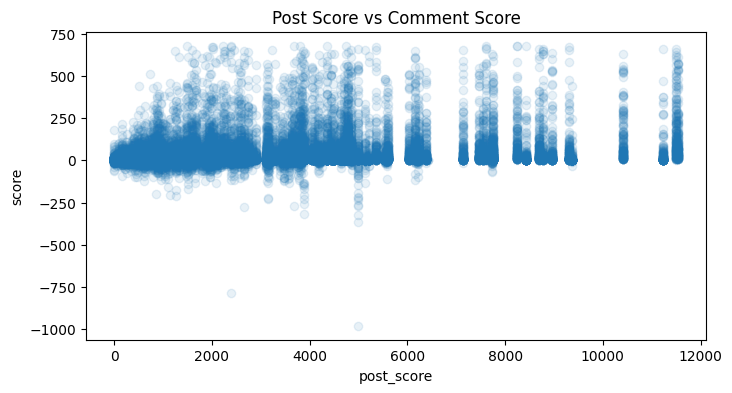

게시물 score - 댓글 score 상관계수: 0.218


In [35]:
#추가적인 궁금증으로 게시물의 score가 높으면 댓글의 score도 높은지 그 상관관계를 찾아봤습니다.
#####게시물 score가 높으면 댓글 score도 높은가?#####

df_filtered2 = df_raw[
    (df_raw['post_score'] < df_raw['post_score'].quantile(0.99)) &
    (df_raw['score'] < df_raw['score'].quantile(0.99))
]

plt.figure(figsize=(8, 4))
plt.scatter(df_filtered2['post_score'], df_filtered2['score'], alpha=0.1)
plt.title('Post Score vs Comment Score')
plt.xlabel('post_score')
plt.ylabel('score')
plt.show()

corr2 = df_raw['post_score'].corr(df_raw['score'])
print(f"게시물 score - 댓글 score 상관계수: {corr2:.3f}")

### **Analysis 2: Post Score vs Comment Score**

이것도 비슷하게 상관계수가 0.218로 1에 한참 못미치긴 하지만 분석 1에 비해서는 높게 보인다. 하지만 산점도에서도 시각적으로 확인해보면 score가 높은 게시물의 댓글 score가 미세하게 많은 것들을 볼 수 있긴하다. 특히 post_score 12000 구간에서 높은 score 댓글이 더 많이 보인다.
결론적으로 여전히 상관관계는 약하나 미세하게 게시물에 따라 댓글 socre가 높아지는 경우도 있다.


The correlation coefficient of 0.218 is still far below 1,
indicating a weak relationship overall. However, it is noticeably
higher than Analysis 1 (0.026), suggesting a slightly stronger connection.

Visually in the scatter plot, posts with higher scores tend to have
marginally more high-score comments. In particular, around the
post_score 12000 range, comments with higher scores are more frequently observed.

In conclusion, while the correlation remains weak, there is a slight tendency
for comment scores to be higher when the post score is high,
unlike karma which showed almost no relationship at all.

## **전체적으로 학습을 위해 주석을 달아놓은점을 양해부탁드립니다!** ⚓